# 1.Importing necessary libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import re
import time
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from urllib.request import urlopen
from bs4 import BeautifulSoup
import requests


# 1. Scraping the Amazon Best Selling Books
# 2. This URL that you are going to scrape is the following: https://www.amazon.in/gp/bestsellers/books/. 

In [33]:
def get_data(pageNo):

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/151.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9"
    }

    url = f"https://www.amazon.in/gp/bestsellers/books?pg={pageNo}"

    r = requests.get(url, headers=headers)

    soup = BeautifulSoup(r.text, "html.parser")

    items = soup.find_all(
        "div",
        class_="zg-grid-general-faceout"
    )

    print(f"Page {pageNo}: Books found: {len(items)}")

    alls = []

    for d in items:

        # Book Name
        img = d.find("img")

        if img and img.get("alt"):
            book_name = img.get("alt")
        else:
            book_name = "Unknown"

        # Author
        author = d.find("a", class_="a-size-small")

        if author:
            author_name = author.get_text(strip=True)
        else:
            author_name = "Unknown"

        # Rating
        rating = d.find("span", class_="a-icon-alt")

        if rating:
            rating_value = rating.get_text(strip=True)
        else:
            rating_value = "Not Available"

        # Customers Rated
        text = d.get_text(" ", strip=True)

        rating_match = re.search(
            r'\d\.\d\s+out of 5 stars\s+([\d,]+)',
            text
        )

        if rating_match:
            customers_rated = rating_match.group(1)
        else:
            customers_rated = "0"

        # Price
        price_match = re.search(
            r'₹[\d,]+(?:\.\d{2})?',
            text
        )

        if price_match:
            price = price_match.group(0)
        else:
            price = "0"

        alls.append([
            book_name,
            author_name,
            rating_value,
            customers_rated,
            price
        ])

    return alls

In [34]:
no_pages = 2

results = []

for i in range(1, no_pages + 1):
    results.append(get_data(i))


# Flatten the list
flatten = lambda l: [
    item
    for sublist in l
    for item in sublist
]


# Create DataFrame
df = pd.DataFrame(
    flatten(results),
    columns=[
        "Book Name",
        "Author",
        "Rating",
        "Customers_Rated",
        "Price"
    ]
)


# Save to CSV
df.to_csv(
    "amazon_products.csv",
    index=False,
    encoding="utf-8"
)


print(f"\nTotal books scraped: {len(df)}")
print("\nFirst 5 records:")
print(df.head())

Page 1: Books found: 30
Page 2: Books found: 30

Total books scraped: 60

First 5 records:
                                           Book Name              Author  \
0  My First Library Boxset For Kids (10 Board Boo...  Wonder House Books   
1                            The Psychology of Money       Morgan Housel   
2    Atomic Habits: Tiny Changes, Remarkable Results         James Clear   
3  PARMAR SSC Fatman | GK/GS Theory Book | Englis...          Parmar Sir   
4  PW EaJEE Handwritten Notes For Organic Chemist...       Rohit Agrawal   

               Rating Customers_Rated    Price  
0  4.5 out of 5 stars          92,037  ₹375.00  
1  4.6 out of 5 stars          83,252  ₹289.00  
2  4.6 out of 5 stars         112,633  ₹482.00  
3  4.5 out of 5 stars             870  ₹429.00  
4  4.4 out of 5 stars             717  ₹470.00  


In [35]:
df = pd.read_csv("amazon_products.csv")

In [36]:
df.shape

(60, 5)

In [37]:
df['Rating'] = df['Rating'].apply(lambda x: x.split()[0])
df['Rating'] = pd.to_numeric(df['Rating'])

In [45]:
df.head()

,Book Name,Author,Rating,Customers_Rated,Price
0,My First Library Boxset For Kids (10 Board Boo...,Wonder House Books,4.5,"92,037",₹375.00
1,The Psychology of Money,Morgan Housel,4.6,"83,252",₹289.00
2,"Atomic Habits: Tiny Changes, Remarkable Results",James Clear,4.6,"112,633",₹482.00
3,PARMAR SSC Fatman | GK/GS Theory Book | Englis...,Parmar Sir,4.5,870,₹429.00
4,PW EaJEE Handwritten Notes For Organic Chemist...,Rohit Agrawal,4.4,717,₹470.00


In [46]:
df["Price"] = df["Price"].str.replace('₹', '')

In [47]:
df.head()

,Book Name,Author,Rating,Customers_Rated,Price
0,My First Library Boxset For Kids (10 Board Boo...,Wonder House Books,4.5,"92,037",375.00
1,The Psychology of Money,Morgan Housel,4.6,"83,252",289.00
2,"Atomic Habits: Tiny Changes, Remarkable Results",James Clear,4.6,"112,633",482.00
3,PARMAR SSC Fatman | GK/GS Theory Book | Englis...,Parmar Sir,4.5,870,429.00
4,PW EaJEE Handwritten Notes For Organic Chemist...,Rohit Agrawal,4.4,717,470.00


In [48]:
df["Price"] = df["Price"].str.replace(',', '')

In [49]:
df['Price'] = df['Price'].apply(lambda x: x.split('.')[0])

In [50]:
df['Price'] = df['Price'].astype(int)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Book Name        60 non-null     str    
 1   Author           60 non-null     str    
 2   Rating           60 non-null     float64
 3   Customers_Rated  60 non-null     str    
 4   Price            60 non-null     int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 2.5 KB


In [52]:
df["Customers_Rated"] = df["Customers_Rated"].str.replace(',', '')

In [54]:
df['Customers_Rated'] = (
    df['Customers_Rated']
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

In [56]:
print(df['Customers_Rated'].head())
print(df['Customers_Rated'].dtype)

0     92037
1     83252
2    112633
3       870
4       717
Name: Customers_Rated, dtype: int64
int64


In [57]:
df.head()

,Book Name,Author,Rating,Customers_Rated,Price
0,My First Library Boxset For Kids (10 Board Boo...,Wonder House Books,4.5,92037,375
1,The Psychology of Money,Morgan Housel,4.6,83252,289
2,"Atomic Habits: Tiny Changes, Remarkable Results",James Clear,4.6,112633,482
3,PARMAR SSC Fatman | GK/GS Theory Book | Englis...,Parmar Sir,4.5,870,429
4,PW EaJEE Handwritten Notes For Organic Chemist...,Rohit Agrawal,4.4,717,470


In [58]:
df.dtypes

Book Name              str
Author                 str
Rating             float64
Customers_Rated      int64
Price                int64
dtype: object

In [59]:
df.replace(str(0), np.nan, inplace=True)
df.replace(0, np.nan, inplace=True)

,Book Name,Author,Rating,Customers_Rated,Price
0,My First Library Boxset For Kids (10 Board Boo...,Wonder House Books,4.5,92037,375
1,The Psychology of Money,Morgan Housel,4.6,83252,289
2,"Atomic Habits: Tiny Changes, Remarkable Results",James Clear,4.6,112633,482
3,PARMAR SSC Fatman | GK/GS Theory Book | Englis...,Parmar Sir,4.5,870,429
4,PW EaJEE Handwritten Notes For Organic Chemist...,Rohit Agrawal,4.4,717,470
5,NCERT CLASS 9 Understanding Society – India an...,National council of educational research and t...,4.1,363,139
6,"SHNMN Sank Magic Practice Copybook, (4 BOOK +1...",QOKZEK,4.2,5663,277
7,Autobiography of a Yogi,Paramahansa Yogananda,4.6,6413,149
8,"Courage To Be Disliked, The: How to free yours...",Unknown,4.5,23274,351
9,My First Library Set of 10 Board Books for Kid...,PW,4.5,1632,369


In [60]:
count_nan = len(df) - df.count()
count_nan

Book Name          0
Author             0
Rating             0
Customers_Rated    0
Price              0
dtype: int64

# 1.Authors' Highest Priced Book on Amazon

In [63]:
data = df.sort_values(["Price"], axis=0, ascending=False)[:10]

In [64]:
data

,Book Name,Author,Rating,Customers_Rated,Price
40,PW Med Easy Zoology 2.0 and Botany Handwritten...,Dr. Vipin Sharma,4.6,570,802
47,Oswaal CBSE Class 10 Mathematics (Standard) Qu...,Oswaal Editorial Board,4.5,1037,625
58,Educart CBSE Class 9 Science Exploration Quest...,Prashant Kirad,4.7,167,586
25,Arihant All in One Science (Exploration) Class...,Siddhartha Shankar,4.5,235,487
2,"Atomic Habits: Tiny Changes, Remarkable Results",James Clear,4.6,112633,482
46,Arihant All in One Science Class 10 for CBSE E...,Alpesh Kumar,4.5,202,473
4,PW EaJEE Handwritten Notes For Organic Chemist...,Rohit Agrawal,4.4,717,470
3,PARMAR SSC Fatman | GK/GS Theory Book | Englis...,Parmar Sir,4.5,870,429
34,PW NEET Easy Handwritten Notes Inorganic Chemi...,Om Pandey,4.6,559,379
41,Pearson 2026 UGC NET Paper 1 Teaching & Resear...,KVS Madaan,4.6,300,378


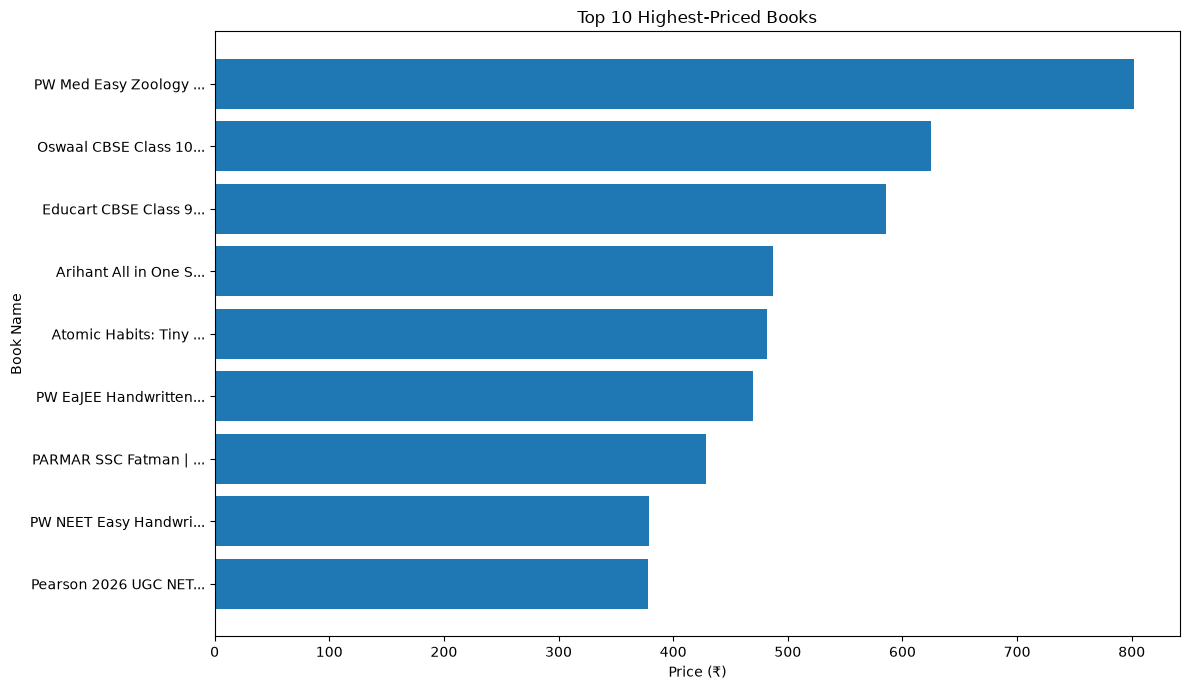

In [68]:
top_10 = df.nlargest(10, "Price").copy()

# Shorten book names only for the chart
top_10["Short Name"] = top_10["Book Name"].str.slice(0, 20) + "..."

# Plot
plt.figure(figsize=(12, 7))

plt.barh(top_10["Short Name"], top_10["Price"])

plt.xlabel("Price (₹)")
plt.ylabel("Book Name")
plt.title("Top 10 Highest-Priced Books")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# 1. Top Rated Books by Authors

In [70]:
data = df[df['Customers_Rated'] > 1000]
data = data.sort_values(['Rating'],axis=0, ascending=False)[:10]
data

,Book Name,Author,Rating,Customers_Rated,Price
38,THE LION INSIDE,Rachel Bright,4.7,9176,319
7,Autobiography of a Yogi,Paramahansa Yogananda,4.6,6413,149
2,"Atomic Habits: Tiny Changes, Remarkable Results",James Clear,4.6,112633,482
10,Ikigai: The Japanese secret to a long and happ...,Héctor García,4.6,62931,321
1,The Psychology of Money,Morgan Housel,4.6,83252,289
50,THE SILENT PATIENT,Alex Michaelides,4.6,268471,254
45,1001 Ultimate Brain Booster Activity book for ...,Team Pegasus,4.6,3009,305
19,The Very Hungry Caterpillar,Eric Carle,4.6,96939,298
12,White Nights by Fyodor Dostoyevsky: A Timeless...,Fyodor Dostoyevsky,4.6,5651,107
42,MURDLE: SOLVE 100 DEVILISHLY DEVIOUS MURDER MY...,G. T. Karber,4.6,7362,370


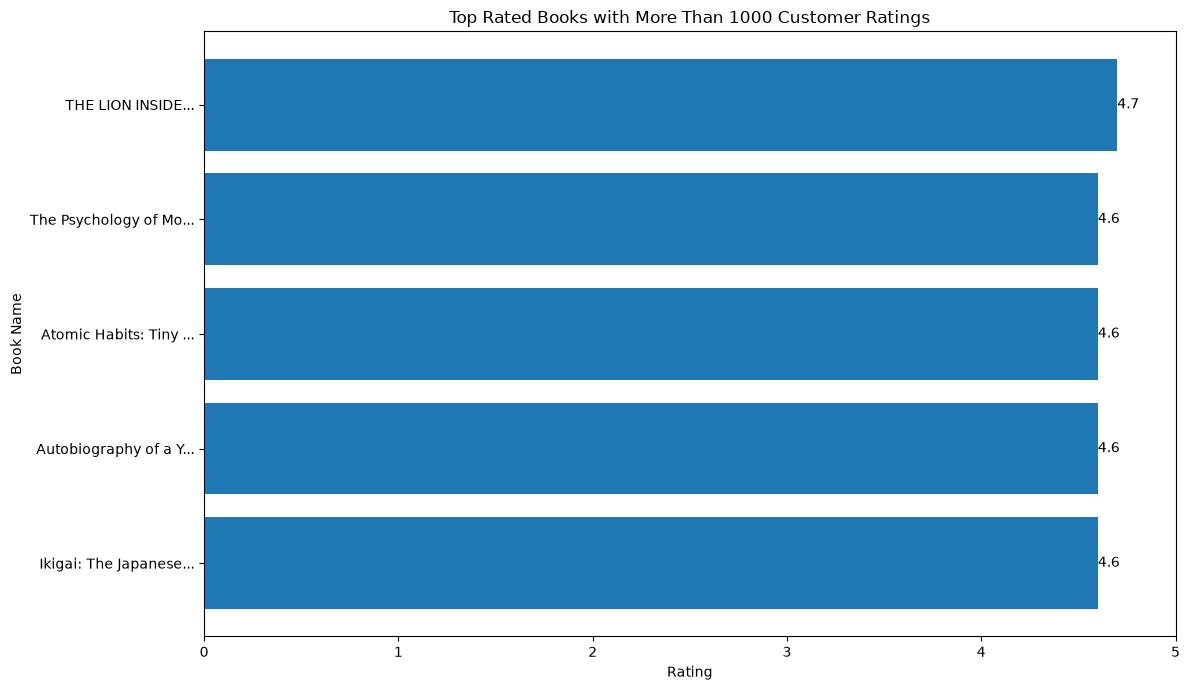

In [77]:
data = df[df["Customers_Rated"] > 1000].nlargest(5, "Rating").copy()

data["Book_Name_Short"] = data["Book Name"].str[:20] + "..."

plt.figure(figsize=(12, 7))

bars = plt.barh(
    data["Book_Name_Short"],
    data["Rating"]
)

plt.xlabel("Rating")
plt.ylabel("Book Name")
plt.title("Top Rated Books with More Than 1000 Customer Ratings")

plt.xlim(0, 5)
plt.gca().invert_yaxis()

# Show rating on each bar
for bar in bars:
    plt.text(
        bar.get_width() + 0.000110,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# 1.Most Customer Rated Authors and Books

In [78]:
data = df.sort_values(["Customers_Rated"], axis=0, ascending=False)[:20]

In [79]:
data

,Book Name,Author,Rating,Customers_Rated,Price
51,Never Lie: A Totally Gripping Thriller with Mi...,The Housemaid Freida McFadden,4.4,350629,328
50,THE SILENT PATIENT,Alex Michaelides,4.6,268471,254
16,The Alchemist,Paulo Coelho,4.6,181418,269
2,"Atomic Habits: Tiny Changes, Remarkable Results",James Clear,4.6,112633,482
19,The Very Hungry Caterpillar,Eric Carle,4.6,96939,298
0,My First Library Boxset For Kids (10 Board Boo...,Wonder House Books,4.5,92037,375
1,The Psychology of Money,Morgan Housel,4.6,83252,289
14,The Power of Your Subconscious Mind: Original ...,Joseph Murphy,4.5,67492,149
10,Ikigai: The Japanese secret to a long and happ...,Héctor García,4.6,62931,321
11,My First Book of Patterns Pencil Control: Patt...,Wonder House Books,4.4,33791,99


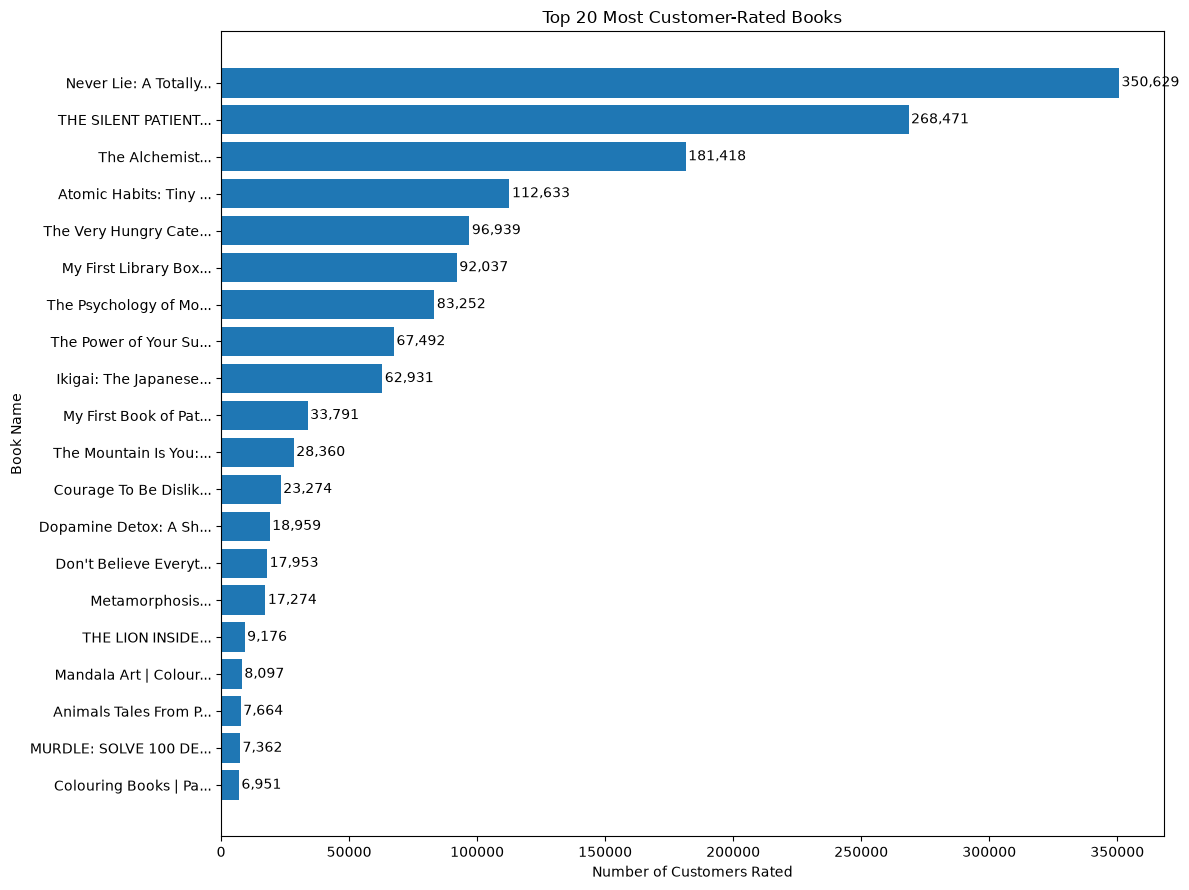

In [84]:
import matplotlib.pyplot as plt

# Select top 20 books by number of customers rated
data = df.nlargest(20, "Customers_Rated").copy()

# Shorten book names for the graph
data["Short_Name"] = data["Book Name"].str[:20] + "..."

# Sort for horizontal bar chart
data = data.sort_values("Customers_Rated")

# Plot
plt.figure(figsize=(12, 9))

bars = plt.barh(
    data["Short_Name"],
    data["Customers_Rated"]
)

plt.xlabel("Number of Customers Rated")
plt.ylabel("Book Name")
plt.title("Top 20 Most Customer-Rated Books")

# Add values at the end of bars
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()